# 비/눈 판별 모델 v1 (시간별 데이터)

**v0(일별)의 한계:** 강수일 전체 정확도는 90%였지만, 평가 기간 **첫눈 10번 중 5번만** 맞혔다.
놓친 첫눈은 모두 **새벽에 잠깐 눈이 오고 낮에는 풀린 날**이라, 하루 평균기온으로는 "비"로 보였다.

**v1의 아이디어:** 하루 평균 대신 **눈이 내린 그 시간의 날씨**를 본다.

```
v0: 하루 평균기온 5.8°C  → "비"
v1: 새벽 4시 기온 3.5°C, 습도 58% → 습구온도 0.0°C → "눈"
```

**설계**
- 데이터: 기상청 ASOS **시간자료** (서울, 2000~2025) - `scripts/download_asos_hourly.py`로 받음
- 대상: 10~4월 중 **비나 눈이 내린 시간**
- 입력: 기온, 습도, **습구온도**, 이슬점, 풍속, 북서풍 여부 → 모두 단기예보(TMP, REH, WSD, VEC)로 계산 가능
- 평가: v0과 똑같이 **2016년 7월 이전으로 학습 → 최근 10시즌으로 평가**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier

from first_snow.data import load_daily, load_hourly, first_snow_dates
from first_snow.features import HOURLY_FEATURES, daily_features
from first_snow.model import build_model, hourly_training_set, training_set

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

TEST_FROM = "2016-07-01"

## 1. 시간자료 확인 - 데이터에서 발견한 두 가지 문제

시간자료의 `현상코드`(국내식 일기현상 코드)로 그 시간에 비·눈이 왔는지 판단한다.
코드는 2자리씩 이어붙어 있다. 예) `0605` = 06(진눈깨비) + 05(눈)

코드의 뜻은 같은 날 일자료의 기사와 맞춰 보고 확인했다 (`src/first_snow/config.py`).

| 구분 | 코드 |
|---|---|
| 비 | 01 비, 02 이슬비, 04 소나기 |
| 눈 | 05 눈, 06 진눈깨비, 08 소낙눈, 09 소낙성진눈깨비, 10 싸락눈, 11 가루눈 |
| 제외 | 12 얼음싸라기, 13 싸락우박, 14 우박 (얼음 알갱이) |

**문제 1. 1996~1999년에는 현상코드가 아예 없다** → 이 기간을 "비·눈 없음"으로 학습하면 안 되므로 "모름(NA)"으로 두고 **2000년부터** 쓴다.

**문제 2. 일부 코드는 맨 앞의 0이 빠져 있다** (`01` → `1`, `0601` → `601`)
→ 그대로 2자리씩 자르면 `601` → `60`, `1`처럼 엉뚱하게 잘린다. 짝수 길이가 되도록 앞에 0을 채운 뒤 자른다.
이 버그를 고치기 전에는 2000년대 초반의 강수 시간이 절반 가까이 빠져 있었다.

In [2]:
from first_snow.config import DATA_DIR

files = sorted((DATA_DIR / "hourly").glob("*.csv"))
raw_codes = pd.concat([pd.read_csv(f, dtype={"dmstMtphNo": str}, usecols=["dmstMtphNo"]) for f in files])
raw_codes = raw_codes["dmstMtphNo"].dropna()
print("맨 앞 0이 빠진 코드 (홀수 길이) 예:", raw_codes[raw_codes.str.len() % 2 == 1].value_counts().head(6).to_dict())

hourly = load_hourly()
yearly = hourly.groupby("연도").agg(
    강수시간=("강수", lambda s: "모름" if s.isna().all() else int(s.sum())),
    눈시간=("눈", lambda s: "모름" if s.isna().all() else int(s.sum())),
)
yearly.T

맨 앞 0이 빠진 코드 (홀수 길이) 예: {'1': 3191, '5': 597, '4': 138, '0': 24, '6': 21, '601': 18}


연도,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
강수시간,모름,모름,모름,모름,1008,871,1197,1353,1056,899,...,905,964,1065,991,1273,1131,1112,1335,1220,1336
눈시간,모름,모름,모름,모름,137,197,126,96,87,119,...,110,140,114,88,111,114,164,143,214,216


## 2. 일별 vs 시간별 - v0이 놓친 2020-12-10 첫눈

In [3]:
day = hourly[hourly["일시"].dt.strftime("%Y-%m-%d") == "2020-12-10"].copy()
daily = load_daily()
print("일자료 평균기온:", daily.loc[daily["일시"] == "2020-12-10", "평균기온(°C)"].iloc[0], "°C")

from first_snow.features import wet_bulb
day["습구온도"] = wet_bulb(day["기온"], day["습도"]).round(1)
day["현상"] = np.where(day["눈"], "눈", np.where(day["강수"], "비", ""))
day[["일시", "기온", "습도", "습구온도", "현상코드", "현상"]].iloc[:12]

일자료 평균기온: 5.8 °C


,일시,기온,습도,습구온도,현상코드,현상
218639,2020-12-10 00:00:00,3.4,59.0,0.0,NaN,
218640,2020-12-10 01:00:00,3.4,58.0,-0.0,NaN,
218641,2020-12-10 02:00:00,3.4,57.0,-0.1,NaN,
218642,2020-12-10 03:00:00,3.5,58.0,0.0,NaN,
218643,2020-12-10 04:00:00,3.5,58.0,0.0,05,눈
218644,2020-12-10 05:00:00,3.6,59.0,0.2,05,눈
218645,2020-12-10 06:00:00,3.6,64.0,0.6,0605,눈
218646,2020-12-10 07:00:00,3.3,69.0,0.6,06,눈
218647,2020-12-10 08:00:00,3.3,68.0,0.6,NaN,
218648,2020-12-10 09:00:00,3.7,66.0,0.8,NaN,


하루 평균은 5.8°C였지만, 눈이 온 새벽 4~7시에도 **기온은 3°C대**였다. 대신 습도가 58~69%로 낮아서 **습구온도는 0°C 근처**였다.

**습구온도란?** 젖은 천으로 감싼 온도계의 온도다. 공기가 건조하면 물이 증발하면서 열을 빼앗아 기온보다 낮아진다.
눈송이도 똑같다. 건조한 공기 속을 떨어지는 눈은 표면이 증발하며 스스로 식어서, 기온이 영상이어도 녹지 않고 땅까지 내려온다.
그래서 비/눈을 가르는 데는 기온보다 습구온도가 더 잘 맞는다.

## 3. 기온 vs 습구온도 - 어느 쪽이 비와 눈을 잘 가르나

강수 12084시간 (눈 3351시간, 28%) / 2000~2025년


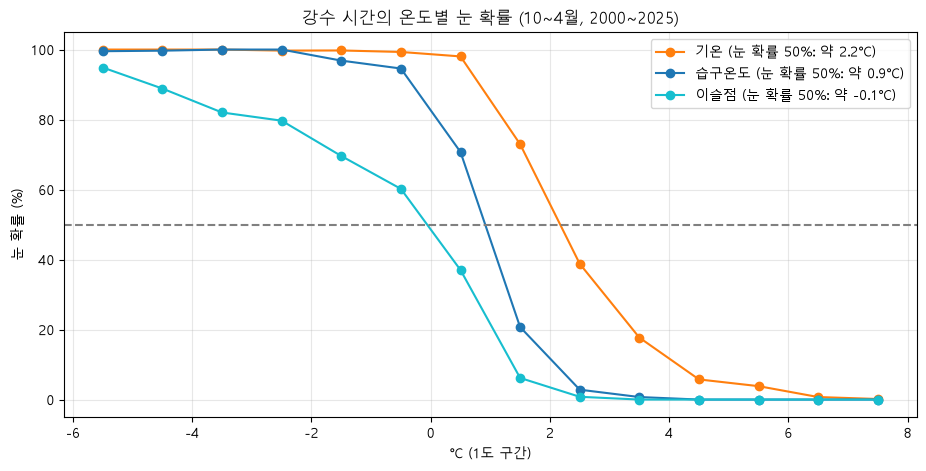

In [4]:
hours, X, y = hourly_training_set(hourly)
print(f"강수 {len(y)}시간 (눈 {y.sum()}시간, {y.mean():.0%}) / {hours['연도'].min()}~{hours['연도'].max()}년")

bins = np.arange(-6, 9, 1)
fig, ax = plt.subplots(figsize=(11, 5))
for col, color in [("기온", "tab:orange"), ("습구온도", "tab:blue"), ("이슬점", "tab:cyan")]:
    g = y.groupby(pd.cut(X[col], bins), observed=True).agg(["mean", "size"])
    g = g[g["size"] >= 20]
    mids = [iv.mid for iv in g.index]
    x50 = np.interp(0.5, g["mean"].values[::-1], np.array(mids)[::-1])
    ax.plot(mids, g["mean"] * 100, marker="o", color=color, label=f"{col} (눈 확률 50%: 약 {x50:.1f}°C)")
ax.axhline(50, color="gray", linestyle="--")
ax.set_xlabel("°C (1도 구간)")
ax.set_ylabel("눈 확률 (%)")
ax.set_title("강수 시간의 온도별 눈 확률 (10~4월, 2000~2025)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

습구온도 곡선이 가장 **가파르다** = 경계가 가장 선명하다.
기온은 1~4°C에서 눈 확률이 완만하게 떨어지지만, 습구온도는 0~2°C 사이에서 거의 눈 → 거의 비로 바뀐다.

## 4. 모델 비교 (평가: 2016/17 ~ 2025 시즌)

In [5]:
train = hours["일시"] < TEST_FROM
test = ~train


def scores(y_true, prob):
    return {"정확도": accuracy_score(y_true, prob >= 0.5),
            "Brier": brier_score_loss(y_true, prob),
            "AUC": roc_auc_score(y_true, prob)}


rows = {}
rows["규칙: 습구온도 ≤ 1°C"] = scores(y[test], (X.loc[test, "습구온도"] <= 1).astype(float))
for cols in [["기온"], ["습구온도"], HOURLY_FEATURES]:
    m = build_model().fit(X.loc[train, cols], y[train])
    name = "로지스틱: " + ("전체 Feature" if cols == HOURLY_FEATURES else " + ".join(cols))
    rows[name] = scores(y[test], m.predict_proba(X.loc[test, cols])[:, 1])
gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300).fit(X[train], y[train])
rows["부스팅: 전체 Feature"] = scores(y[test], gbm.predict_proba(X[test])[:, 1])

pd.DataFrame(rows).T.round(3)

,정확도,Brier,AUC
규칙: 습구온도 ≤ 1°C,0.966,0.034,0.956
로지스틱: 기온,0.946,0.041,0.987
로지스틱: 습구온도,0.959,0.029,0.994
로지스틱: 전체 Feature,0.960,0.029,0.994
부스팅: 전체 Feature,0.956,0.030,0.993


- 습구온도 하나만으로도 기온보다 확실히 좋다 (Brier 0.041 → 0.029, AUC 0.987 → 0.994).
- 규칙(습구온도 ≤ 1°C)은 정확도가 가장 높지만(0.966), 0/1로만 답해서 **확률을 줄 수 없고** AUC가 낮다 (애매한 시간을 구분하지 못함).
- 전체 Feature 로지스틱과 부스팅은 비슷하다 → 해석이 쉬운 **로지스틱 회귀 + 전체 Feature**를 v1으로 쓴다.
- 참고로 v0(일별)은 같은 기간 강수일 기준 정확도 0.903, Brier 0.071, AUC 0.965였다.

로지스틱 회귀 계수 (표준화 기준)
기온     -4.01
습구온도   -3.75
이슬점    -3.40
풍속     -0.11
북서풍     0.23
습도      0.58


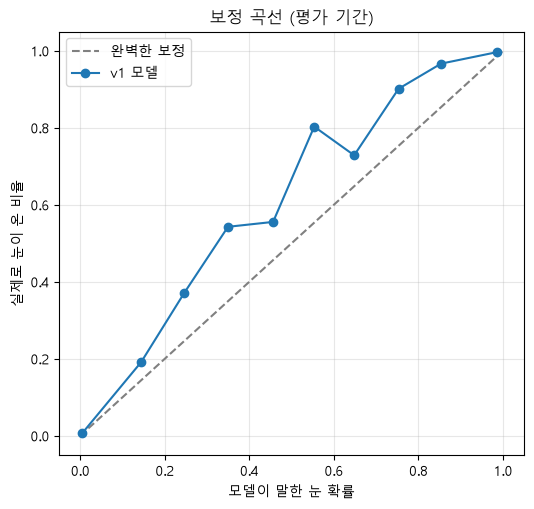

In [6]:
model = build_model().fit(X[train], y[train])
prob = model.predict_proba(X[test])[:, 1]

# 계수: 표준화된 입력 기준. 음수 = 값이 클수록 눈 확률이 낮아짐
coef = pd.Series(model[-1].coef_[0], index=HOURLY_FEATURES).round(2)
print("로지스틱 회귀 계수 (표준화 기준)")
print(coef.sort_values().to_string())

bins = np.linspace(0, 1, 11)
idx = np.digitize(prob, bins[1:-1])
calib = pd.DataFrame({"예측": prob, "실제": y[test].to_numpy(), "구간": idx}).groupby("구간").agg(
    평균예측=("예측", "mean"), 실제비율=("실제", "mean"), 시간수=("실제", "size"))

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="완벽한 보정")
ax.plot(calib["평균예측"], calib["실제비율"], marker="o", label="v1 모델")
ax.set_xlabel("모델이 말한 눈 확률")
ax.set_ylabel("실제로 눈이 온 비율")
ax.set_title("보정 곡선 (평가 기간)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

- 보정 곡선이 대각선 근처 → "눈일 확률 70%"라고 하면 실제로 70% 안팎으로 눈이 왔다.
- 계수는 기온·습구온도·이슬점이 모두 크게 음수(따뜻할수록 비)다. 다만 세 값이 서로 강하게 겹쳐서, 계수 하나하나의 크기를 따로 해석하지는 않는다.

## 5. 첫눈을 맞히나? (v0 vs v1)

서비스의 핵심 질문이다. 평가 기간 각 해의 첫눈 날에 대해:
- **v0:** 그날 일별 날씨로 계산한 눈 확률
- **v1:** 그날 비·눈이 내린 시간들 중 **가장 높은** 눈 확률 (그날 한 번이라도 눈이 올 가능성)

확률 50% 이상이면 "맞힘"으로 본다.

In [7]:
# v0 (일별) - 같은 기간으로 학습
days, Xd, yd = training_set(daily)
v0 = build_model().fit(Xd[days["일시"] < TEST_FROM], yd[days["일시"] < TEST_FROM])

# v1 날짜별 최고 확률 (평가 기간 모델로 전체 강수 시간 예측)
hours_p = hours.assign(확률=model.predict_proba(X)[:, 1])
day_max = hours_p.groupby(hours_p["일시"].dt.normalize())["확률"].max()

fs = first_snow_dates(daily)
fs = fs[fs["일시"] >= TEST_FROM].copy()
fs["v0 확률"] = v0.predict_proba(daily_features(fs))[:, 1]
fs["v1 확률"] = fs["일시"].map(day_max)

result = fs.set_index("일시")[["v0 확률", "v1 확률"]].round(2)
print(f"첫눈 적중 (≥50%): v0 {(result['v0 확률'] >= 0.5).sum()}/10, v1 {(result['v1 확률'] >= 0.5).sum()}/10")
result

첫눈 적중 (≥50%): v0 5/10, v1 9/10


,v0 확률,v1 확률
일시,,
2016-11-26,0.84,0.95
2017-11-17,0.59,0.76
2018-11-24,0.58,1.00
2019-11-15,0.10,0.98
2020-12-10,0.08,0.55
2021-11-10,0.20,0.78
2022-11-29,0.01,1.00
2023-11-17,0.67,0.52
2024-11-26,0.04,0.46


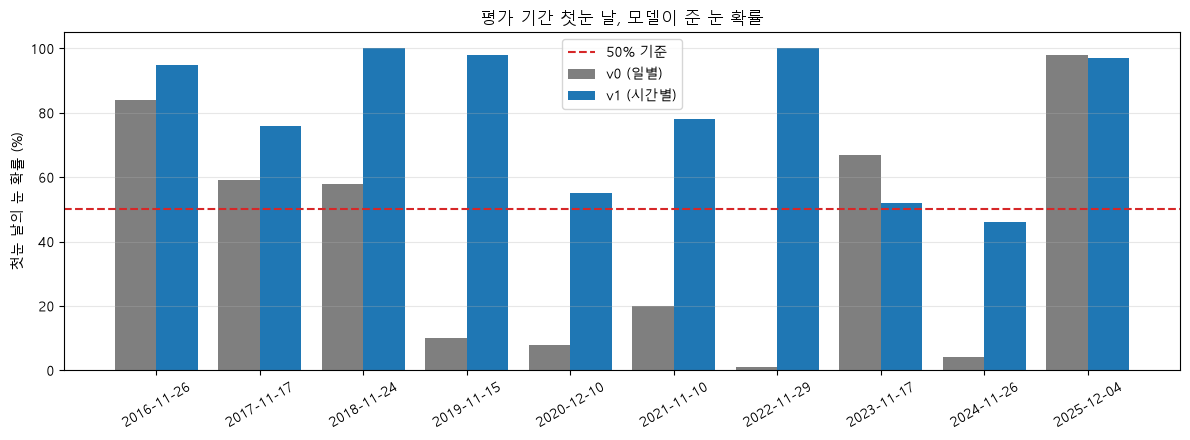

In [8]:
fig, ax = plt.subplots(figsize=(12, 4.5))
xs = np.arange(len(result))
ax.bar(xs - 0.2, result["v0 확률"] * 100, width=0.4, label="v0 (일별)", color="tab:gray")
ax.bar(xs + 0.2, result["v1 확률"] * 100, width=0.4, label="v1 (시간별)", color="tab:blue")
ax.axhline(50, color="tab:red", linestyle="--", label="50% 기준")
ax.set_xticks(xs, result.index.strftime("%Y-%m-%d"), rotation=30)
ax.set_ylabel("첫눈 날의 눈 확률 (%)")
ax.set_title("평가 기간 첫눈 날, 모델이 준 눈 확률")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 6. 헛알림은 없나?

v1은 하루 중 **가장 높은** 시간 확률을 쓰므로, 비만 온 날에도 한 시간쯤 확률이 튀어서 "눈"이라고 할 위험이 있다.
서비스에서 이것은 **"첫눈 올 것 같아요" 헛알림**이 된다.

평가 기간 각 해에서 **첫눈 전에 비가 온 날**(= 첫눈 알림이 나가면 안 되는 날)을 모두 모아, 50% 이상을 준 날을 센다.

In [9]:
daily_p = days.assign(v0=v0.predict_proba(Xd)[:, 1], v1=days["일시"].map(day_max))
first_by_year = first_snow_dates(daily).set_index("연도")["일시"]

rows = []
for year in range(2016, 2026):
    before = daily_p[(daily_p["연도"] == year) & (daily_p["일시"].dt.month >= 9)
                     & (daily_p["일시"] < first_by_year[year])]
    rows.append({"연도": year, "첫눈 전 강수일": len(before),
                 "v0 헛알림": int((before["v0"] >= 0.5).sum()),
                 "v1 헛알림": int((before["v1"] >= 0.5).sum()),
                 "v1 최고 확률": round(before["v1"].max(), 2)})
false_alarm = pd.DataFrame(rows).set_index("연도")
print(f"첫눈 전 강수일 {false_alarm['첫눈 전 강수일'].sum()}일 중 헛알림: "
      f"v0 {false_alarm['v0 헛알림'].sum()}번, v1 {false_alarm['v1 헛알림'].sum()}번")
false_alarm

첫눈 전 강수일 172일 중 헛알림: v0 1번, v1 0번


,첫눈 전 강수일,v0 헛알림,v1 헛알림,v1 최고 확률
연도,,,,
2016,23,1,0,0.46
2017,14,0,0,0.02
2018,18,0,0,0.09
2019,10,0,0,0.00
2020,15,0,0,0.21
2021,18,0,0,0.14
2022,15,0,0,0.00
2023,14,0,0,0.00
2024,20,0,0,0.00


## 7. 정리

| | v0 (일별) | v1 (시간별) |
|---|---|---|
| 정확도 | 90.3% | **96.0%** |
| AUC | 0.965 | **0.994** |
| Brier (낮을수록 좋음) | 0.071 | **0.029** |
| **첫눈 적중** | 5/10 | **9/10** |
| **헛알림** | 1번 | **0번** |

**무엇이 좋아졌나**
- **시간 단위**로 보니 새벽에 잠깐 온 첫눈을 그 시간의 날씨로 잡아낸다.
- **습구온도**가 기온보다 비/눈 경계를 선명하게 가른다. 건조한 공기에서는 기온이 3°C여도 눈이 온다.
- 하루 중 최고 확률을 써도, 첫눈 전 비 온 날에 헛알림은 없었다. (가장 아슬아슬했던 날은 2016년의 46%)

**한계**
- 놓친 1번(2024-11-26)은 확률 46%, 2023·2020년 첫눈도 52~55%로 아슬아슬했다.
  → 서비스에서는 50% 하나로 자르기보다 "가능성 높음 / 있음" 처럼 단계로 보여주는 게 좋다.
- 이 평가는 **실제 관측값**을 넣은 결과다. 서비스에서는 **예보값**이 들어가므로, 예보 오차만큼 성능이 떨어질 수 있다.
  → 2026년 11~12월 시즌에 실제 예보로 운영해서 확인한다.
- 모델은 "비나 눈이 내린다면 눈일까?"만 판단한다. 강수 여부 자체는 기상청 예보(강수확률 POP)에 맡긴다.

**다음:** 기상청 단기예보를 받아 v1으로 "내일·모레 첫눈 가능성"을 계산하는 모듈 (2단계)